In [5]:
from src.ColorsAnalysis import *
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
plt.style.use('properties.mplstyle')

In [6]:
savepath = "../results/ColorAnalysis/3D"
create_folder(savepath)

Folder already exists: ../results/ColorAnalysis/3D


In [7]:
process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

def parse_params_from_path(dat_path: Path) -> dict:
    """
    Extrai metadados do caminho:
    {base_root}/{type}_percolation/num_colors_{nc}/dim_{dim}/L_{L}/NT_constant/NT_{Nt}/k_{k}/rho_{rho}/data/all_data.dat
    """
    s = str(dat_path)

    def grab(pattern, cast):
        m = re.search(pattern, s)
        return cast(m.group(1)) if m else None

    return {
        "dim":        grab(r"/dim_(\d+)(?:/|$)", int),
        "L":          grab(r"/L_(\d+)(?:/|$)", int),
        "Nt":         grab(r"/NT_(\d+)(?:/|$)", int),
        "k":          grab(r"/k_([^/]+)(?:/|$)", float),
        "num_colors": grab(r"/num_colors_(\d+)(?:/|$)", int),
        "rho":        grab(r"/rho_([^/]+)(?:/|$)", float),
        "type_perc":  grab(r"/(bond|node)_percolation(?:/|$)", str),
    }

def nc_from_all_data(dat_path: Path) -> pd.DataFrame:
    df = pd.read_csv(dat_path, sep=r"\s+", engine="python")

    df["p_mean"] = pd.to_numeric(df.get("p_mean"), errors="coerce")
    df["p0"]     = pd.to_numeric(df.get("p0"), errors="coerce")

    # (1) Por seed (filename): conta quantas ordens percolaram (p_mean não-NaN)
    per_seed = (
        df.assign(percolated=df["p_mean"].notna())
          .groupby(["filename", "p0"], as_index=False)["percolated"].sum()
          .rename(columns={"percolated": "n_perc"})
    )

    # (2) Agrega por p0: nc = média(n_perc), nc_err = SEM(n_perc)
    agg = (
        per_seed.groupby("p0", as_index=False)
                .agg(nc=("n_perc", "mean"),
                     nc_std=("n_perc", lambda s: s.std(ddof=1)),
                     Nsamples=("n_perc", "size"))
    )

    agg["nc_err"] = np.where(agg["Nsamples"] > 1, agg["nc_std"] / np.sqrt(agg["Nsamples"]), 0.0)
    return agg[["p0", "Nsamples", "nc", "nc_err"]]

def build_and_save_nc_analysis(base_root="../Data", dat_filename="all_data.dat") -> dict:
    """
    Varre base_root, calcula nc/nc_err e salva:
      base_root/{type_perc}_percolation/nc_analysis.dat

    Retorna dict: {"bond": df_bond, "node": df_node}
    """
    base_root = Path(base_root)
    per_type = {"bond": [], "node": []}

    for dat_path in base_root.glob(f"**/data/{dat_filename}"):
        params = parse_params_from_path(dat_path)
        t = params.get("type_perc")
        if t not in per_type:
            continue

        out = nc_from_all_data(dat_path)

        # injeta metadados do path
        out["L"]          = params["L"]
        out["dim"]        = params["dim"]
        out["Nt"]         = params["Nt"]
        out["k"]          = params["k"]
        out["num_colors"] = params["num_colors"]
        out["rho"]        = params["rho"]

        # ordem FINAL exigida
        out = out[["L", "dim", "Nt", "k", "num_colors", "p0", "Nsamples", "rho", "nc", "nc_err"]]
        per_type[t].append(out)

    results = {}
    for t in ("bond", "node"):
        if per_type[t]:
            df_t = pd.concat(per_type[t], ignore_index=True)
            df_t = df_t.sort_values(["L", "dim", "Nt", "k", "num_colors", "p0", "rho"]).reset_index(drop=True)

            out_path = base_root / f"{t}_percolation" / "nc_analysis.dat"
            out_path.parent.mkdir(parents=True, exist_ok=True)
            df_t.to_csv(out_path, sep=" ", index=False)

            results[t] = df_t
        else:
            results[t] = pd.DataFrame(columns=["L","dim","Nt","k","num_colors","p0","Nsamples","rho","nc","nc_err"])

    return results


In [3]:
df_final = build_and_save_nc_analysis(base_root="../Data")

In [8]:
df = pd.read_csv("../Data/bond_percolation/nc_analysis.dat", sep=' ')
df

,L,dim,Nt,k,num_colors,p0,Nsamples,rho,nc,nc_err
0,128,3,3000,0.000001,2,1.0,2000,0.001000,0.000000,0.000000
1,128,3,3000,0.000001,2,1.0,2000,0.003508,0.000000,0.000000
2,128,3,3000,0.000001,2,1.0,2000,0.006015,0.000000,0.000000
3,128,3,3000,0.000001,2,1.0,1700,0.008523,0.823529,0.023880
4,128,3,3000,0.000001,2,1.0,1500,0.011030,0.666667,0.024351
...,...,...,...,...,...,...,...,...,...,...
2036,4096,2,400,0.000010,4,1.0,50,0.125000,4.000000,0.000000
2037,4096,2,400,0.000010,8,1.0,50,0.125000,8.000000,0.000000
2038,8192,2,400,0.000010,2,1.0,10,0.125000,2.000000,0.000000
2039,8192,2,400,0.000010,4,1.0,10,0.125000,4.000000,0.000000


In [11]:
df = df[(df['dim']==3)]

## 2 COLORS

## 4 COLORS

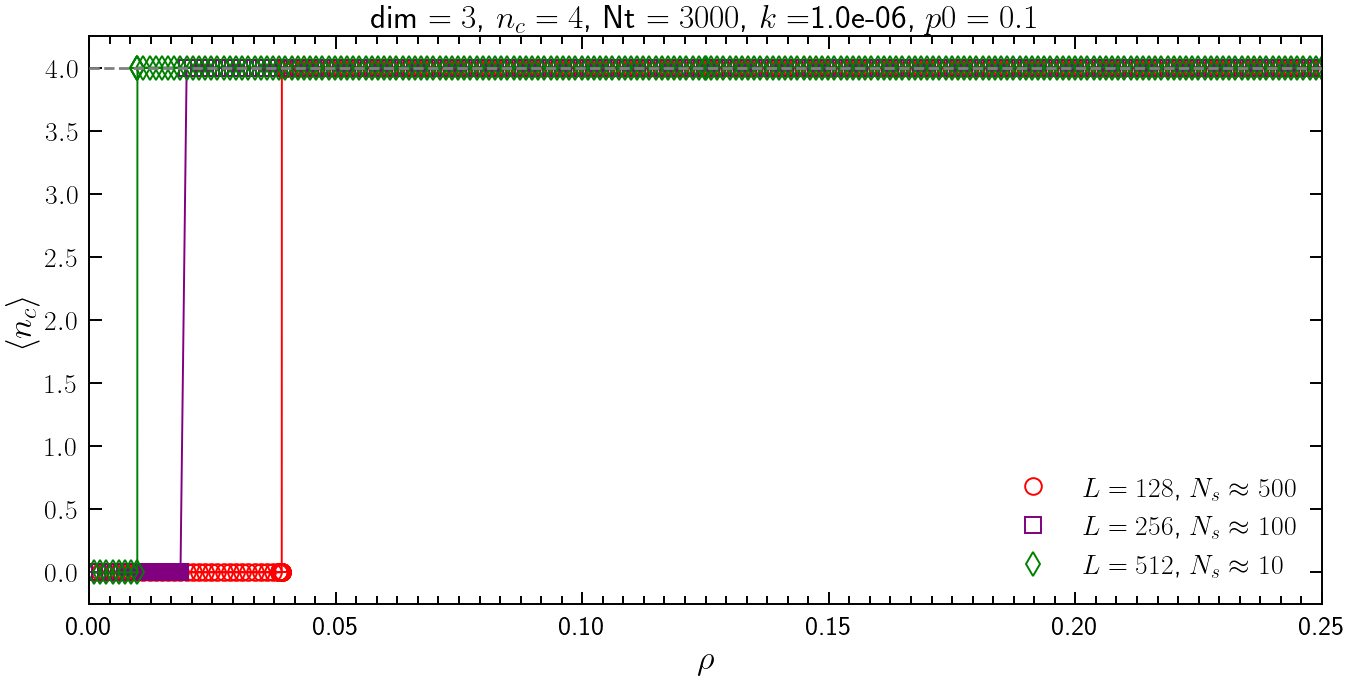

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# -------- parâmetros do plot --------
num_colors_fix = 4
L_lst  = [128, 256, 512]

Nt_fix = 3000
k_fix  = 1.0e-06
dim = 3 
ms = 12
font_tick_size = 20
font_label_size = 25
font_legend_size = 20
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]
mew = 1.4
p0=0.1
thickness = 1.4

# se quiser fixar dim explicitamente (2 ou 3), defina aqui:
# dim_fix = 2
# dim_fix = 3
# ou deixe como None para não filtrar
dim_fix = None

# se quiser fixar p0 (recomendado se existir mais de um no df), defina aqui:
# p0_fix = 1.0
p0_fix = None


def nc_by_rho_from_df(df, n_colors, L, k, Nt, dim=None, p0=None):
    sel = df.copy()

    sel = sel[sel["num_colors"] == n_colors]
    sel = sel[sel["L"] == L]

    if dim is not None:
        sel = sel[sel["dim"] == dim]

    if k is not None:
        sel = sel[np.isclose(sel["k"].astype(float), float(k), rtol=1e-12, atol=0.0)]

    if Nt is not None:
        sel = sel[sel["Nt"] == Nt]

    if p0 is not None:
        sel = sel[np.isclose(sel["p0"].astype(float), float(p0), rtol=1e-12, atol=0.0)]

    if sel.empty:
        return pd.DataFrame(columns=["rho", "nc", "nc_err", "Nsamples"])

    # (rho é float, garanta ordenação)
    sel["rho"] = sel["rho"].astype(float)
    sel = sel.sort_values("rho").reset_index(drop=True)

    # Se ainda existir mais de um p0 por rho (p0_fix=None e dataset tem múltiplos p0),
    # agregue por rho usando média ponderada por Nsamples.
    if p0 is None and sel.groupby("rho")["p0"].nunique().max() > 1:
        def _wmean(g):
            w = g["Nsamples"].to_numpy(dtype=float)
            y = g["nc"].to_numpy(dtype=float)
            e = g["nc_err"].to_numpy(dtype=float)

            wsum = w.sum()
            if wsum <= 0:
                return pd.Series({"nc": np.nan, "nc_err": np.nan, "Nsamples": 0})

            nc_w = np.sum(w * y) / wsum
            # propagação simples de erro (assumindo independência)
            nc_err_w = np.sqrt(np.sum((w * e) ** 2)) / wsum

            return pd.Series({"nc": nc_w, "nc_err": nc_err_w, "Nsamples": int(wsum)})

        sel = sel.groupby("rho", as_index=False).apply(_wmean)

    return sel[["rho", "nc", "nc_err", "Nsamples"]]


# ===== Figura e eixo principais =====
fig, ax = plt.subplots(figsize=(14, 7))
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))

legend_handles = []

for idx, L in enumerate(L_lst):
    res = nc_by_rho_from_df(df, n_colors=num_colors_fix, L=L, k=k_fix, Nt=Nt_fix,
                           dim=dim_fix, p0=p0_fix)
    if res.empty:
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]

    # usa erro do próprio dataframe
    ax.errorbar(
        res["rho"], res["nc"], yerr=res["nc_err"],
        fmt=fmt, color=color, linewidth=thickness,
        ms=ms, markeredgewidth=mew, zorder=2,
        capsize=4, elinewidth=thickness
    )

    # Nsamples pode variar com rho; escolha um resumo (min) para o label
    ns_label = int(np.nanmin(res["Nsamples"].to_numpy())) if len(res) else 0

    label = fr"$L={L}$, $N_s\approx{ns_label}$"
    legend_handles.append(Line2D(
        [], [], linestyle='None',
        marker=fmt[0], markersize=ms,
        markeredgewidth=mew, markerfacecolor='none',
        markeredgecolor=color, color=color, label=label
    ))

# ----- eixo principal -----
ax.axhline(y=num_colors_fix, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, num_colors_fix + 0.25])

ax.set_xlim(0.0, 1.0/num_colors_fix)
major_locator = np.linspace(0.0, 1.0/num_colors_fix, 6)
minor_locator = np.linspace(0.0, 1.0/num_colors_fix, 61)
ax.set_xticks(major_locator)
ax.set_xticks(minor_locator, minor=True)
ax.set_xticklabels([f"{tick:.2f}" for tick in major_locator])

ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower right", frameon=False)

plt.tight_layout()

# título
if dim_fix is not None:
    ax.set_title(f"dim = {dim_fix}")
else:
    ax.set_title(rf"dim $= {dim}$, $n_c = {num_colors_fix}$, $N_t$ $= {Nt_fix}$, $k = ${k_fix:.1e}, $p0 = {p0}$")

fig.savefig(
    savepath + f"/nc_{num_colors_fix}_dim_{dim}.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)
plt.show()


In [3]:
df_sub = df[(df['dim']==3) & (df["L"]==512) & (df["num_colors"]==4)]
df_nc0 = df_sub[np.isclose(df_sub["nc"], 0.0)]
df_nc0['rho'].unique()

df_sub_sorted = df_sub.sort_values("rho")

mask = ~np.isclose(df_sub_sorted["nc"], 0.0)  # tolerância p/ float
df_first = df_sub_sorted.loc[mask].iloc[0] if mask.any() else None
df_first

L              512.000000
dim              3.000000
Nt            3000.000000
k                0.000001
num_colors       4.000000
p0               1.000000
Nsamples        50.000000
rho              0.009771
nc               4.000000
nc_err           0.000000
Name: 1624, dtype: float64

## 8 COLORS

NameError: name 'dim' is not defined

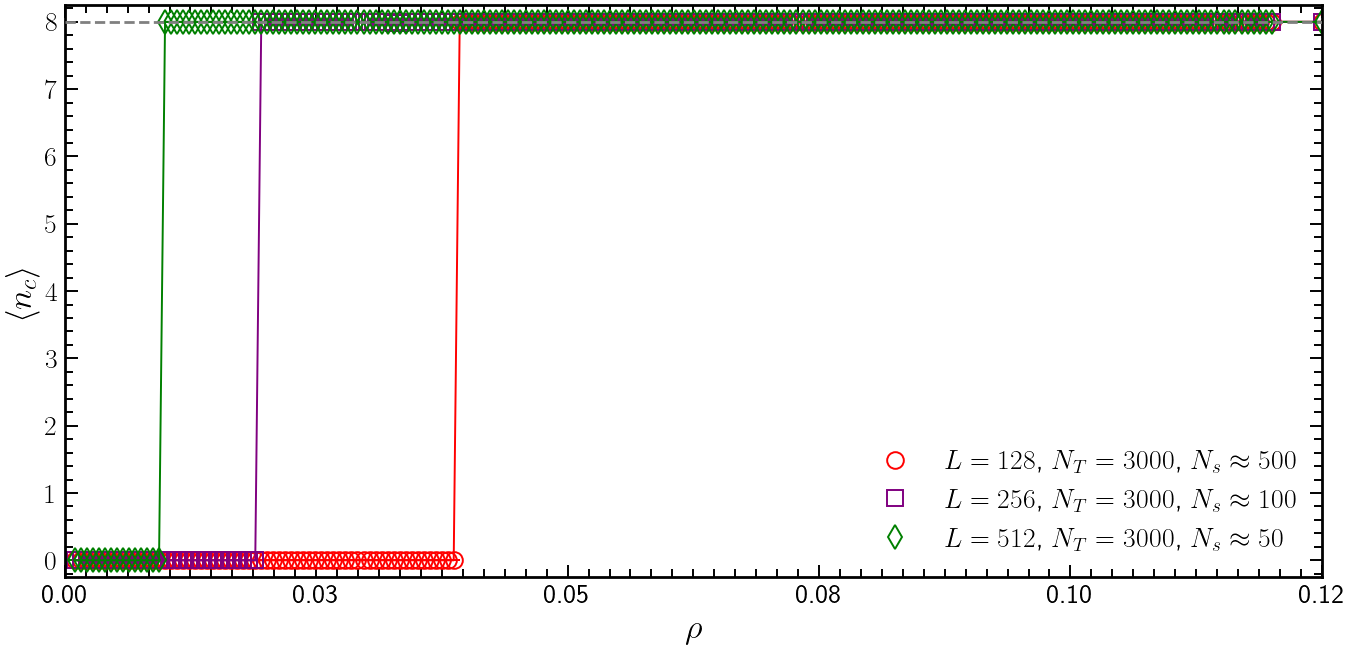

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# -------- parâmetros do plot --------
num_colors_fix = 8
L_lst  = [128, 256, 512]

Nt_fix = 3000
k_fix  = 1.0e-06

ms = 12
font_tick_size = 20
font_label_size = 25
font_legend_size = 20
colors  = ["red", "purple", "green", "blue"]
markers = ["o-", "s-", "d-", "^-"]
mew = 1.4
thickness = 1.4

# se quiser fixar dim explicitamente (2 ou 3), defina aqui:
# dim_fix = 2
# dim_fix = 3
# ou deixe como None para não filtrar
dim_fix = None

# se quiser fixar p0 (recomendado se existir mais de um no df), defina aqui:
# p0_fix = 1.0
p0_fix = None


def nc_by_rho_from_df(df, n_colors, L, k, Nt, dim=None, p0=None):
    sel = df.copy()

    sel = sel[sel["num_colors"] == n_colors]
    sel = sel[sel["L"] == L]

    if dim is not None:
        sel = sel[sel["dim"] == dim]

    if k is not None:
        sel = sel[np.isclose(sel["k"].astype(float), float(k), rtol=1e-12, atol=0.0)]

    if Nt is not None:
        sel = sel[sel["Nt"] == Nt]

    if p0 is not None:
        sel = sel[np.isclose(sel["p0"].astype(float), float(p0), rtol=1e-12, atol=0.0)]

    if sel.empty:
        return pd.DataFrame(columns=["rho", "nc", "nc_err", "Nsamples"])

    # (rho é float, garanta ordenação)
    sel["rho"] = sel["rho"].astype(float)
    sel = sel.sort_values("rho").reset_index(drop=True)

    # Se ainda existir mais de um p0 por rho (p0_fix=None e dataset tem múltiplos p0),
    # agregue por rho usando média ponderada por Nsamples.
    if p0 is None and sel.groupby("rho")["p0"].nunique().max() > 1:
        def _wmean(g):
            w = g["Nsamples"].to_numpy(dtype=float)
            y = g["nc"].to_numpy(dtype=float)
            e = g["nc_err"].to_numpy(dtype=float)

            wsum = w.sum()
            if wsum <= 0:
                return pd.Series({"nc": np.nan, "nc_err": np.nan, "Nsamples": 0})

            nc_w = np.sum(w * y) / wsum
            # propagação simples de erro (assumindo independência)
            nc_err_w = np.sqrt(np.sum((w * e) ** 2)) / wsum

            return pd.Series({"nc": nc_w, "nc_err": nc_err_w, "Nsamples": int(wsum)})

        sel = sel.groupby("rho", as_index=False).apply(_wmean)

    return sel[["rho", "nc", "nc_err", "Nsamples"]]


# ===== Figura e eixo principais =====
fig, ax = plt.subplots(figsize=(14, 7))
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))

legend_handles = []

for idx, L in enumerate(L_lst):
    res = nc_by_rho_from_df(df, n_colors=num_colors_fix, L=L, k=k_fix, Nt=Nt_fix,
                           dim=dim_fix, p0=p0_fix)
    if res.empty:
        continue

    fmt   = markers[idx % len(markers)]
    color = colors [idx % len(colors)]

    # usa erro do próprio dataframe
    ax.errorbar(
        res["rho"], res["nc"], yerr=res["nc_err"],
        fmt=fmt, color=color, linewidth=thickness,
        ms=ms, markeredgewidth=mew, zorder=2,
        capsize=4, elinewidth=thickness
    )

    # Nsamples pode variar com rho; escolha um resumo (min) para o label
    ns_label = int(np.nanmin(res["Nsamples"].to_numpy())) if len(res) else 0

    label = fr"$L={L}$, $N_T={Nt_fix}$, $N_s\approx{ns_label}$"
    legend_handles.append(Line2D(
        [], [], linestyle='None',
        marker=fmt[0], markersize=ms,
        markeredgewidth=mew, markerfacecolor='none',
        markeredgecolor=color, color=color, label=label
    ))

# ----- eixo principal -----
ax.axhline(y=num_colors_fix, color='gray', linestyle='--', lw=2.0, zorder=100)
ax.set_xlabel(r"$\rho$", fontsize=font_label_size)
ax.set_ylabel(r"$\langle n_c \rangle$", fontsize=font_label_size)
ax.set_ylim([-0.25, num_colors_fix + 0.25])

ax.set_xlim(0.0, 1.0/num_colors_fix)
major_locator = np.linspace(0.0, 1.0/num_colors_fix, 6)
minor_locator = np.linspace(0.0, 1.0/num_colors_fix, 61)
ax.set_xticks(major_locator)
ax.set_xticks(minor_locator, minor=True)
ax.set_xticklabels([f"{tick:.2f}" for tick in major_locator])

ax.tick_params(axis='both', which='major', labelsize=font_tick_size, length=9, width=thickness)
ax.tick_params(axis='x',   which='minor', length=6, width=thickness)

ax.legend(handles=legend_handles, fontsize=font_legend_size, loc="lower right", frameon=False)

plt.tight_layout()

# título
if dim_fix is not None:
    ax.set_title(f"dim = {dim_fix}")
else:
    ax.set_title(rf"dim $= {dim}$, $n_c = {num_colors_fix}$, $N_t$ $= {Nt_fix}$, $k = ${k_fix:.1e}, $p0 = {p0}$")

fig.savefig(
    savepath + f"/nc_{num_colors_fix}_dim_{dim}.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05
)
plt.show()


In [11]:
df_sub = df[(df['dim']==3) & (df["L"]==128) & (df["num_colors"]==8)]
df_nc0 = df_sub[np.isclose(df_sub["nc"], 0.0)]
df_nc0['rho'].unique()

df_sub_sorted = df_sub.sort_values("rho")

mask = ~np.isclose(df_sub_sorted["nc"], 0.0)  # tolerância p/ float
df_first = df_sub_sorted.loc[mask].iloc[0] if mask.any() else None
df_first

L              128.000000
dim              3.000000
Nt            3000.000000
k                0.000001
num_colors       8.000000
p0               1.000000
Nsamples       500.000000
rho              0.039271
nc               8.000000
nc_err           0.000000
Name: 565, dtype: float64

In [16]:
df.head()

,L,n_colors,NT,n_c,n_c_err,rho,k,Nsamples
0,128,2,1600,2.0,0.0,0.000100,0.00001,1000
1,128,2,1600,2.0,0.0,0.006428,0.00001,1000
2,128,2,1600,2.0,0.0,0.012756,0.00001,1000
3,128,2,1600,2.0,0.0,0.019084,0.00001,1000
4,128,2,1600,2.0,0.0,0.025411,0.00001,1000


In [17]:
df["Nsamples"].unique()

array([1000,  500,   50,  100,  150,    2,  250,  300,  242,   13])

In [20]:
df[df["Nsamples"]==50]

,L,n_colors,NT,n_c,n_c_err,rho,k,Nsamples
160,512,2,26000,2.0,0.0,0.000010,8.000000e-07,50
161,512,2,26000,2.0,0.0,0.000015,8.000000e-07,50
162,512,2,26000,2.0,0.0,0.000020,8.000000e-07,50
163,512,2,26000,2.0,0.0,0.000025,8.000000e-07,50
164,512,2,26000,2.0,0.0,0.000030,8.000000e-07,50
...,...,...,...,...,...,...,...,...
916,512,4,26000,0.0,0.0,0.244980,8.000000e-07,50
917,512,4,26000,0.0,0.0,0.246230,8.000000e-07,50
918,512,4,26000,0.0,0.0,0.247490,8.000000e-07,50
919,512,4,26000,0.0,0.0,0.248740,8.000000e-07,50
